<a href="https://colab.research.google.com/github/nkocjan/computational-intelligence-methods/blob/dev/lab02/lab02.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Lab 02

Proszę pobrać plik medicine.txt, zawierający wyniki analizy nowego leku. W dwóch pierwszych kolumnach znajduje się stężenie dwóch składników w próbce krwi, w trzeciej - informacja o tym, czy lek zadziałał. Dane nie są znormalizowane. Proszę znormalizować dane, podzielić je na zbiór uczący i testujący w proporcjach 80-20 (należy pamiętać o proporcjach klas), zaproponować wielowarstwową sieć neuronową i zbadać jej skuteczność dla różnych ilości warstw i neuronów w tych warstwach. Proszę narysować w jaki sposób sieć dokonała podziału w zbiorze dla kilku sieci (zarówno tych z dobrymi, jak i złymi wynikami) oraz jak wygląda poprawny podział zbioru. Proszę również przedstawić wyniki dla 5-8 różnych struktur sieci, wraz z oceną, która z nich najlepiej poradziła sobie z zadaniem klasyfikacji.

In [95]:
#Wymagane importy
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.preprocessing import MinMaxScaler
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report, confusion_matrix
from sklearn.datasets import load_digits

Wczytanie danych z pliku

In [59]:
data = pd.read_csv('./medicine.txt', delimiter=",")

Wczytanie danych do zmiennych X oraz y

In [79]:
X = data.iloc[:,:-1]
y = data.iloc[:, -1]

Sprawdzamy czy istnieją i usuwamy outliery

In [80]:
Q1 = X.quantile(0.25)
Q3 = X.quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

mask = ~((X < lower_bound) | (X > upper_bound)).any(axis=1)
X = X[mask]
y = y[mask]

print(f"Usunięto {data.shape[0] - X_filtered.shape[0]} wartości odstających")

Usunięto 65 wartości odstających


Rozbicie danych na trenujące i testujące

In [81]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2,stratify = y, random_state=0)

Normalizacja danych z użyciem MinMaxScaler

In [82]:
scaler = MinMaxScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)
X = scaler.transform(X)

Zdefiniowanie funkcji do rysowania granicy decyzyjnej

In [83]:
def plot_decision_boundary(model, X, y, grid_size=100, x_range=(-1.5, 1.5), y_range=(-1.5, 1.5)):
    xx, yy = np.meshgrid(
        np.linspace(x_range[0], x_range[1], grid_size),
        np.linspace(y_range[0], y_range[1], grid_size)
    )

    test_points = np.c_[xx.ravel(), yy.ravel()]
    predictions = model.predict(test_points).reshape(xx.shape)

    plt.figure(figsize=(8, 6))
    plt.contourf(xx, yy, predictions, alpha=0.6, cmap='coolwarm')
    plt.scatter(X[:, 0], X[:, 1], c=y, edgecolors='k', s=100, cmap='coolwarm')
    plt.title("Granica decyzyjna dla MLP")
    plt.xlabel("x1")
    plt.ylabel("x2")
    plt.show()

Zdefiniowanie funkcji do wypisywania danych do analizy

In [86]:
def evaluate_classification(model, X_test, y_test):
    predicted_labels_test = model.predict(X_test)
    accuracy = accuracy_score(y_test, predicted_labels_test)
    precision = precision_score(y_test, predicted_labels_test, average='weighted')
    recall = recall_score(y_test, predicted_labels_test, average='weighted')
    f1 = f1_score(y_test, predicted_labels_test, average='weighted')

    print(f"Dokładność: {accuracy:.4f}")
    print(f"Precyzja: {precision:.4f}")
    print(f"Czułość: {recall:.4f}")
    print(f"Miara F1: {f1:.4f}")

    # Szczegółowy raport klasyfikacji
    print("\nRaport klasyfikacji:\n", classification_report(y_test, predicted_labels_test))

1. Próba dla 2 warstw, każda po 5 neuronów.

Score na zbiorze treningowym: 0.9008
Score na zbiorze testowym: 0.9222
Dokładność: 0.9222
Precyzja: 0.9225
Czułość: 0.9222
Miara F1: 0.9223

Raport klasyfikacji:
               precision    recall  f1-score   support

           0       0.94      0.93      0.93       149
           1       0.90      0.92      0.91       108

    accuracy                           0.92       257
   macro avg       0.92      0.92      0.92       257
weighted avg       0.92      0.92      0.92       257



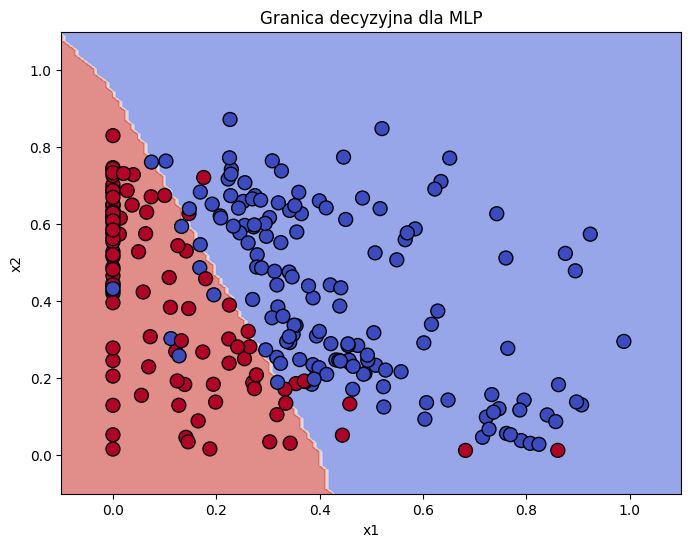

In [87]:
model = MLPClassifier(hidden_layer_sizes = (5,5), max_iter=2000)
model.fit(X_train, y_train)

train_score = model.score(X_train, y_train)
test_score = model.score(X_test, y_test)

print(f'Score na zbiorze treningowym: {train_score:.4f}')
print(f'Score na zbiorze testowym: {test_score:.4f}')
evaluate_classification(model, X_test, y_test)
plot_decision_boundary(model, X_test, y_test, x_range=(-0.1, 1.1), y_range=(-0.1, 1.1))

2. Próba dla 5 warstw po 3 neurony

Score na zbiorze treningowym: 0.9027
Score na zbiorze testowym: 0.9300
Dokładność: 0.9300
Precyzja: 0.9307
Czułość: 0.9300
Miara F1: 0.9301

Raport klasyfikacji:
               precision    recall  f1-score   support

           0       0.95      0.93      0.94       149
           1       0.90      0.94      0.92       108

    accuracy                           0.93       257
   macro avg       0.93      0.93      0.93       257
weighted avg       0.93      0.93      0.93       257



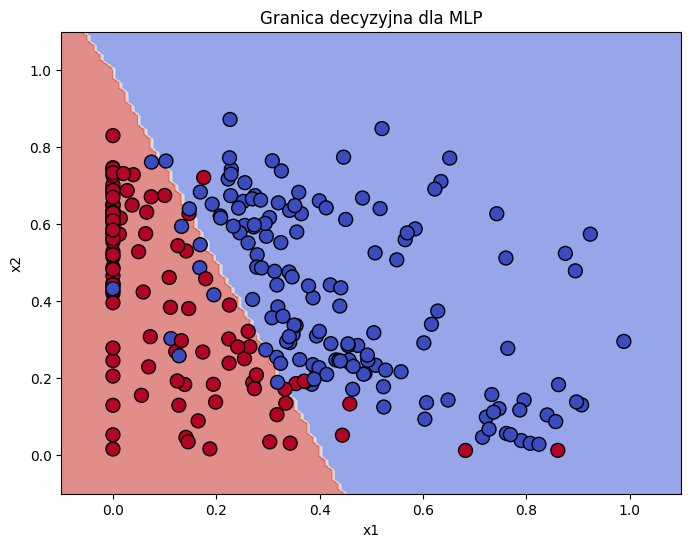

In [88]:
model = MLPClassifier(hidden_layer_sizes = (3,3,3,3,3), max_iter=2000)
model.fit(X_train, y_train)

train_score = model.score(X_train, y_train)
test_score = model.score(X_test, y_test)

print(f'Score na zbiorze treningowym: {train_score:.4f}')
print(f'Score na zbiorze testowym: {test_score:.4f}')
evaluate_classification(model, X_test, y_test)
plot_decision_boundary(model, X_test, y_test, x_range=(-0.1, 1.1), y_range=(-0.1, 1.1))

3. Próba dla dwócch wartstw po 25 neuronów

Score na zbiorze treningowym: 0.9144
Score na zbiorze testowym: 0.9339
Dokładność: 0.9339
Precyzja: 0.9349
Czułość: 0.9339
Miara F1: 0.9340

Raport klasyfikacji:
               precision    recall  f1-score   support

           0       0.96      0.93      0.94       149
           1       0.90      0.94      0.92       108

    accuracy                           0.93       257
   macro avg       0.93      0.94      0.93       257
weighted avg       0.93      0.93      0.93       257



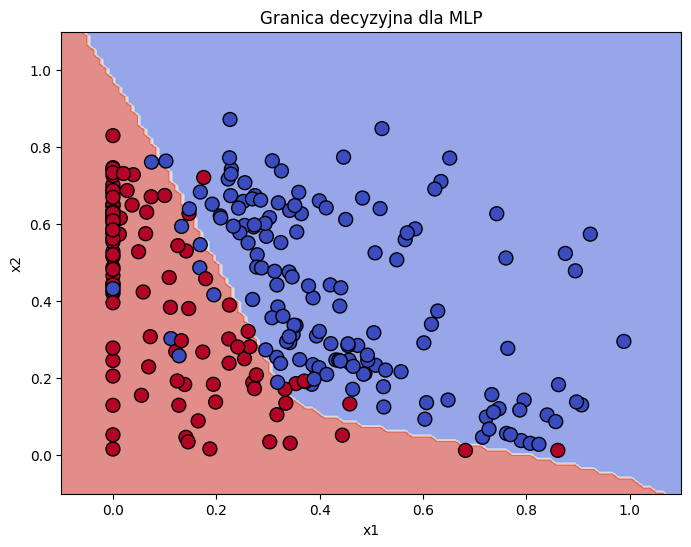

In [90]:
model = MLPClassifier(hidden_layer_sizes = (25,25), max_iter=2000)
model.fit(X_train, y_train)

train_score = model.score(X_train, y_train)
test_score = model.score(X_test, y_test)

print(f'Score na zbiorze treningowym: {train_score:.4f}')
print(f'Score na zbiorze testowym: {test_score:.4f}')
evaluate_classification(model, X_test, y_test)
plot_decision_boundary(model, X_test, y_test, x_range=(-0.1, 1.1), y_range=(-0.1, 1.1))

4. Próba dla dwóch wartstw po 100 neuronów

Score na zbiorze treningowym: 0.9163
Score na zbiorze testowym: 0.9339
Dokładność: 0.9339
Precyzja: 0.9357
Czułość: 0.9339
Miara F1: 0.9341

Raport klasyfikacji:
               precision    recall  f1-score   support

           0       0.96      0.92      0.94       149
           1       0.90      0.95      0.92       108

    accuracy                           0.93       257
   macro avg       0.93      0.94      0.93       257
weighted avg       0.94      0.93      0.93       257



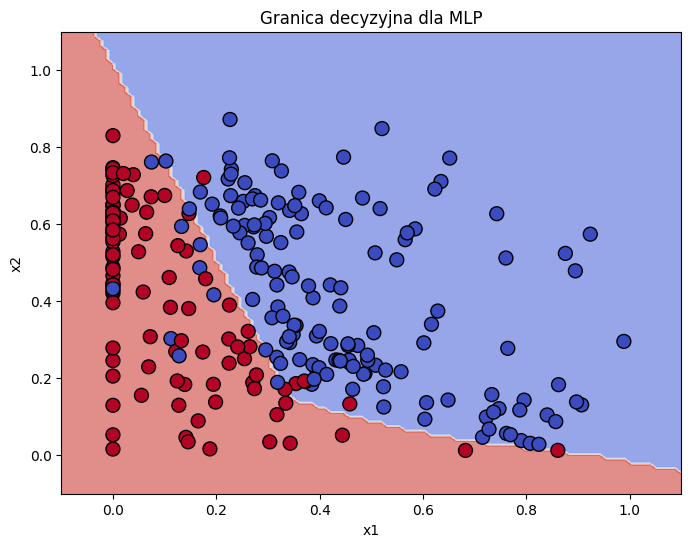

In [91]:
model = MLPClassifier(hidden_layer_sizes = (100,100), max_iter=2000)
model.fit(X_train, y_train)

train_score = model.score(X_train, y_train)
test_score = model.score(X_test, y_test)

print(f'Score na zbiorze treningowym: {train_score:.4f}')
print(f'Score na zbiorze testowym: {test_score:.4f}')
evaluate_classification(model, X_test, y_test)
plot_decision_boundary(model, X_test, y_test, x_range=(-0.1, 1.1), y_range=(-0.1, 1.1))

5. Próba dla 2 warstw po 1000 nauronów

Score na zbiorze treningowym: 0.9173
Score na zbiorze testowym: 0.9183
Dokładność: 0.9183
Precyzja: 0.9225
Czułość: 0.9183
Miara F1: 0.9187

Raport klasyfikacji:
               precision    recall  f1-score   support

           0       0.96      0.89      0.93       149
           1       0.87      0.95      0.91       108

    accuracy                           0.92       257
   macro avg       0.91      0.92      0.92       257
weighted avg       0.92      0.92      0.92       257



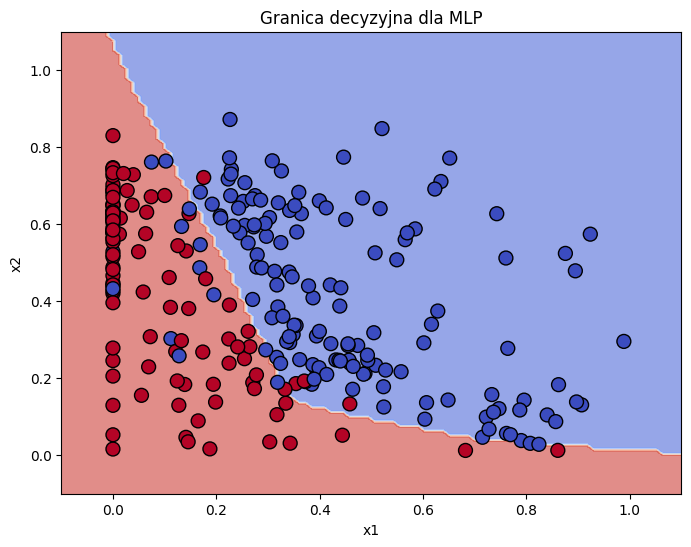

In [92]:
model = MLPClassifier(hidden_layer_sizes = (1000,1000), max_iter=2000)
model.fit(X_train, y_train)

train_score = model.score(X_train, y_train)
test_score = model.score(X_test, y_test)

print(f'Score na zbiorze treningowym: {train_score:.4f}')
print(f'Score na zbiorze testowym: {test_score:.4f}')
evaluate_classification(model, X_test, y_test)
plot_decision_boundary(model, X_test, y_test, x_range=(-0.1, 1.1), y_range=(-0.1, 1.1))

6. Próba dla 3 warstw po 100 neuronów

Score na zbiorze treningowym: 0.9173
Score na zbiorze testowym: 0.9377
Dokładność: 0.9377
Precyzja: 0.9385
Czułość: 0.9377
Miara F1: 0.9379

Raport klasyfikacji:
               precision    recall  f1-score   support

           0       0.96      0.93      0.95       149
           1       0.91      0.94      0.93       108

    accuracy                           0.94       257
   macro avg       0.93      0.94      0.94       257
weighted avg       0.94      0.94      0.94       257



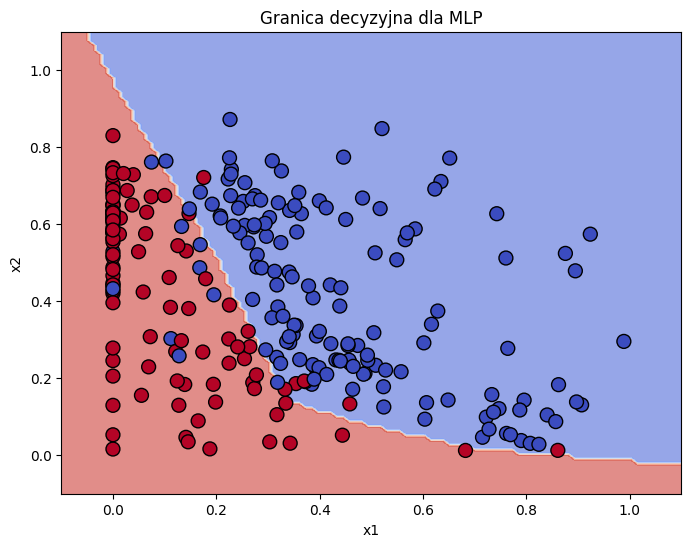

In [93]:
model = MLPClassifier(hidden_layer_sizes = (100,100,100), max_iter=2000)
model.fit(X_train, y_train)

train_score = model.score(X_train, y_train)
test_score = model.score(X_test, y_test)

print(f'Score na zbiorze treningowym: {train_score:.4f}')
print(f'Score na zbiorze testowym: {test_score:.4f}')
evaluate_classification(model, X_test, y_test)
plot_decision_boundary(model, X_test, y_test, x_range=(-0.1, 1.1), y_range=(-0.1, 1.1))

7. Próba dla 10 warstw po 2 neurony

Score na zbiorze treningowym: 0.5778
Score na zbiorze testowym: 0.5798
Dokładność: 0.5798
Precyzja: 0.3361
Czułość: 0.5798
Miara F1: 0.4255

Raport klasyfikacji:
               precision    recall  f1-score   support

           0       0.58      1.00      0.73       149
           1       0.00      0.00      0.00       108

    accuracy                           0.58       257
   macro avg       0.29      0.50      0.37       257
weighted avg       0.34      0.58      0.43       257



/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/m

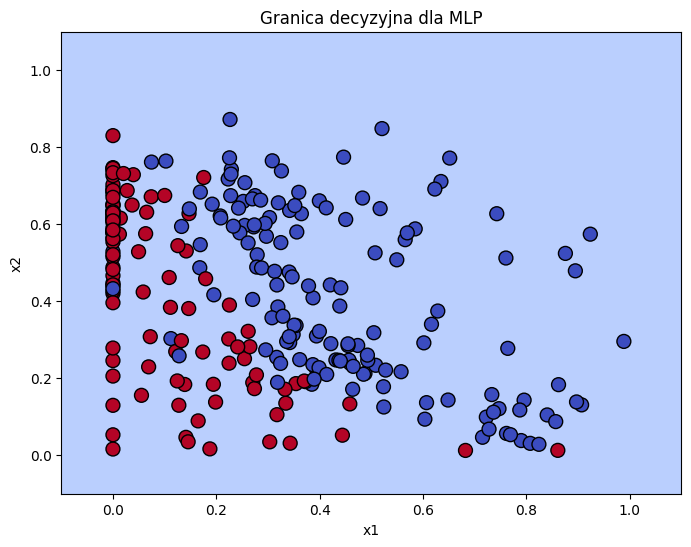

In [94]:
model = MLPClassifier(hidden_layer_sizes = (2,2,2,2,2,2,2,2), max_iter=2000)
model.fit(X_train, y_train)

train_score = model.score(X_train, y_train)
test_score = model.score(X_test, y_test)

print(f'Score na zbiorze treningowym: {train_score:.4f}')
print(f'Score na zbiorze testowym: {test_score:.4f}')
evaluate_classification(model, X_test, y_test)
plot_decision_boundary(model, X_test, y_test, x_range=(-0.1, 1.1), y_range=(-0.1, 1.1))

**Zadanie 2**

Proszę pobrać zbiór ręcznie pisanych cyfr z https://archive.ics.uci.edu/ml/datasets/Optical+Recognition+of+Handwritten+Digits (można to zrobić funkcją datasets.load_digits() w sklearnie). Proszę sprawdzić skuteczność klasyfikacji na tym zbiorze za pomocą wielowarstwowej sieci neuronowej.

Pobranie danych

In [98]:
digits = load_digits()
X, y = digits.data, digits.target

Usuwanie outlinerów jeśli istnieją, ( nie ma )

Podział danych

In [99]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=0)

Skalowanie danych

In [100]:
scaler = MinMaxScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

1. Test dla 2 warstw po 5 neuronów

In [102]:
model = MLPClassifier(hidden_layer_sizes = (5,5), max_iter=2000)
model.fit(X_train, y_train)

train_score = model.score(X_train, y_train)
test_score = model.score(X_test, y_test)

print(f'Score na zbiorze treningowym: {train_score:.4f}')
print(f'Score na zbiorze testowym: {test_score:.4f}')
evaluate_classification(model, X_test, y_test)

Score na zbiorze treningowym: 0.9485
Score na zbiorze testowym: 0.8944
Dokładność: 0.8944
Precyzja: 0.8949
Czułość: 0.8944
Miara F1: 0.8922

Raport klasyfikacji:
               precision    recall  f1-score   support

           0       1.00      0.86      0.93        36
           1       0.82      0.86      0.84        36
           2       0.84      0.91      0.88        35
           3       0.85      0.95      0.90        37
           4       0.94      0.94      0.94        36
           5       0.92      0.97      0.95        37
           6       0.95      1.00      0.97        36
           7       0.92      1.00      0.96        36
           8       0.82      0.66      0.73        35
           9       0.88      0.78      0.82        36

    accuracy                           0.89       360
   macro avg       0.89      0.89      0.89       360
weighted avg       0.89      0.89      0.89       360



2. Test dla 3 warstw po 5 neutronów

In [104]:
model = MLPClassifier(hidden_layer_sizes = (5,5,5), max_iter=2000)
model.fit(X_train, y_train)

train_score = model.score(X_train, y_train)
test_score = model.score(X_test, y_test)

print(f'Score na zbiorze treningowym: {train_score:.4f}')
print(f'Score na zbiorze testowym: {test_score:.4f}')
evaluate_classification(model, X_test, y_test)

Score na zbiorze treningowym: 0.9443
Score na zbiorze testowym: 0.8861
Dokładność: 0.8861
Precyzja: 0.8890
Czułość: 0.8861
Miara F1: 0.8863

Raport klasyfikacji:
               precision    recall  f1-score   support

           0       0.97      0.94      0.96        36
           1       0.84      0.89      0.86        36
           2       0.81      0.83      0.82        35
           3       0.79      0.92      0.85        37
           4       0.97      0.86      0.91        36
           5       1.00      0.97      0.99        37
           6       0.89      0.89      0.89        36
           7       0.92      0.97      0.95        36
           8       0.82      0.77      0.79        35
           9       0.88      0.81      0.84        36

    accuracy                           0.89       360
   macro avg       0.89      0.89      0.89       360
weighted avg       0.89      0.89      0.89       360



3. Test dla 4 warstw po 5 neutronów

In [105]:
model = MLPClassifier(hidden_layer_sizes = (5,5,5,5), max_iter=2000)
model.fit(X_train, y_train)

train_score = model.score(X_train, y_train)
test_score = model.score(X_test, y_test)

print(f'Score na zbiorze treningowym: {train_score:.4f}')
print(f'Score na zbiorze testowym: {test_score:.4f}')
evaluate_classification(model, X_test, y_test)

Score na zbiorze treningowym: 0.8107
Score na zbiorze testowym: 0.7111
Dokładność: 0.7111
Precyzja: 0.6981
Czułość: 0.7111
Miara F1: 0.6898

Raport klasyfikacji:
               precision    recall  f1-score   support

           0       0.00      0.00      0.00        36
           1       0.80      0.78      0.79        36
           2       0.76      0.83      0.79        35
           3       0.81      0.81      0.81        37
           4       0.97      0.89      0.93        36
           5       0.73      0.43      0.54        37
           6       0.94      0.94      0.94        36
           7       0.37      0.89      0.52        36
           8       0.79      0.74      0.76        35
           9       0.81      0.81      0.81        36

    accuracy                           0.71       360
   macro avg       0.70      0.71      0.69       360
weighted avg       0.70      0.71      0.69       360



4. Test dla 5 warstw po 5 neutronów

In [107]:
model = MLPClassifier(hidden_layer_sizes = (5,5,5,5,5), max_iter=2000)
model.fit(X_train, y_train)

train_score = model.score(X_train, y_train)
test_score = model.score(X_test, y_test)

print(f'Score na zbiorze treningowym: {train_score:.4f}')
print(f'Score na zbiorze testowym: {test_score:.4f}')
evaluate_classification(model, X_test, y_test)

Score na zbiorze treningowym: 0.8163
Score na zbiorze testowym: 0.7611
Dokładność: 0.7611
Precyzja: 0.7674
Czułość: 0.7611
Miara F1: 0.7594

Raport klasyfikacji:
               precision    recall  f1-score   support

           0       0.75      0.75      0.75        36
           1       0.70      0.78      0.74        36
           2       0.83      0.83      0.83        35
           3       0.74      0.84      0.78        37
           4       1.00      0.75      0.86        36
           5       0.63      0.65      0.64        37
           6       0.83      0.83      0.83        36
           7       0.71      0.89      0.79        36
           8       0.68      0.49      0.57        35
           9       0.81      0.81      0.81        36

    accuracy                           0.76       360
   macro avg       0.77      0.76      0.76       360
weighted avg       0.77      0.76      0.76       360



5. Test dla 2 warstw po 100 neuronów

In [109]:
model = MLPClassifier(hidden_layer_sizes = (100, 100), max_iter=2000)
model.fit(X_train, y_train)

train_score = model.score(X_train, y_train)
test_score = model.score(X_test, y_test)

print(f'Score na zbiorze treningowym: {train_score:.4f}')
print(f'Score na zbiorze testowym: {test_score:.4f}')
evaluate_classification(model, X_test, y_test)

Score na zbiorze treningowym: 1.0000
Score na zbiorze testowym: 0.9778
Dokładność: 0.9778
Precyzja: 0.9787
Czułość: 0.9778
Miara F1: 0.9780

Raport klasyfikacji:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00        36
           1       0.90      0.97      0.93        36
           2       1.00      0.97      0.99        35
           3       0.97      1.00      0.99        37
           4       1.00      0.97      0.99        36
           5       0.97      0.97      0.97        37
           6       1.00      0.97      0.99        36
           7       1.00      1.00      1.00        36
           8       0.94      0.94      0.94        35
           9       1.00      0.97      0.99        36

    accuracy                           0.98       360
   macro avg       0.98      0.98      0.98       360
weighted avg       0.98      0.98      0.98       360



**Zadanie 3**

Proszę sprawdzić, jak zmieni się poprawność klasyfikacji na zbiorze ręcznie pisanych cyfr dla różnych architektur sieci, funkcji aktywacji, ilości epok uczenia i algorytmów uczenia. Proszę zbadać wpływ współczynnika uczenia (learning_rate) podczas używania algorytmu SGD. Dla najciekawszych przykładów proszę wypisać macierze pomyłek oraz wyliczyć wszystkie poznane metryki.

Tesy dla różnych funkcji aktywacji:

In [112]:
f_aktywacji = np.array(['identity','logistic', 'tanh', 'relu'])
for f in f_aktywacji:
    model = MLPClassifier(hidden_layer_sizes = (5, 5), max_iter=2000, activation=f)
    model.fit(X_train, y_train)
    train_score = model.score(X_train, y_train)
    test_score = model.score(X_test, y_test)

    print(f'Score na zbiorze treningowym: {train_score:.4f}')
    print(f'Score na zbiorze testowym: {test_score:.4f}')
    evaluate_classification(model, X_test, y_test)

Score na zbiorze treningowym: 0.9937
Score na zbiorze testowym: 0.9306
Dokładność: 0.9306
Precyzja: 0.9340
Czułość: 0.9306
Miara F1: 0.9312

Raport klasyfikacji:
               precision    recall  f1-score   support

           0       0.97      0.97      0.97        36
           1       0.78      0.89      0.83        36
           2       0.91      0.91      0.91        35
           3       0.90      0.97      0.94        37
           4       0.97      0.92      0.94        36
           5       0.97      0.97      0.97        37
           6       0.92      0.97      0.95        36
           7       0.97      0.92      0.94        36
           8       0.97      0.86      0.91        35
           9       0.97      0.92      0.94        36

    accuracy                           0.93       360
   macro avg       0.93      0.93      0.93       360
weighted avg       0.93      0.93      0.93       360



/usr/local/lib/python3.11/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (2000) reached and the optimization hasn't converged yet.
  warnings.warn(


Score na zbiorze treningowym: 0.9847
Score na zbiorze testowym: 0.9250
Dokładność: 0.9250
Precyzja: 0.9275
Czułość: 0.9250
Miara F1: 0.9253

Raport klasyfikacji:
               precision    recall  f1-score   support

           0       0.97      0.94      0.96        36
           1       0.85      0.94      0.89        36
           2       0.89      0.91      0.90        35
           3       0.92      0.89      0.90        37
           4       1.00      0.89      0.94        36
           5       0.92      0.97      0.95        37
           6       0.90      0.97      0.93        36
           7       1.00      0.97      0.99        36
           8       0.82      0.80      0.81        35
           9       1.00      0.94      0.97        36

    accuracy                           0.93       360
   macro avg       0.93      0.92      0.92       360
weighted avg       0.93      0.93      0.93       360

Score na zbiorze treningowym: 0.9930
Score na zbiorze testowym: 0.9000
Dokładn

Testy dla różnych ilości epok:

In [113]:
il_epok = np.array([100, 500, 1000, 2000])
for il in il_epok:
    model = MLPClassifier(hidden_layer_sizes = (5, 5), max_iter=il)
    model.fit(X_train, y_train)

    print(f'Score na zbiorze treningowym: {model.score(X_train, y_train):.4f}')
    print(f'Score na zbiorze testowym: {model.score(X_test, y_test):.4f}')
    evaluate_classification(model, X_test, y_test)

/usr/local/lib/python3.11/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (100) reached and the optimization hasn't converged yet.
  warnings.warn(


Score na zbiorze treningowym: 0.7370
Score na zbiorze testowym: 0.7361
Dokładność: 0.7361
Precyzja: 0.7363
Czułość: 0.7361
Miara F1: 0.7347

Raport klasyfikacji:
               precision    recall  f1-score   support

           0       0.89      0.92      0.90        36
           1       0.60      0.72      0.66        36
           2       0.58      0.63      0.60        35
           3       0.78      0.86      0.82        37
           4       0.79      0.75      0.77        36
           5       0.86      0.84      0.85        37
           6       0.83      0.81      0.82        36
           7       0.71      0.67      0.69        36
           8       0.48      0.40      0.44        35
           9       0.82      0.75      0.78        36

    accuracy                           0.74       360
   macro avg       0.73      0.73      0.73       360
weighted avg       0.74      0.74      0.73       360



/usr/local/lib/python3.11/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (500) reached and the optimization hasn't converged yet.
  warnings.warn(


Score na zbiorze treningowym: 0.9443
Score na zbiorze testowym: 0.9028
Dokładność: 0.9028
Precyzja: 0.9103
Czułość: 0.9028
Miara F1: 0.9017

Raport klasyfikacji:
               precision    recall  f1-score   support

           0       0.95      0.97      0.96        36
           1       0.70      0.89      0.78        36
           2       0.87      0.97      0.92        35
           3       0.89      0.92      0.91        37
           4       0.97      0.92      0.94        36
           5       1.00      0.95      0.97        37
           6       0.92      0.94      0.93        36
           7       1.00      0.97      0.99        36
           8       0.91      0.60      0.72        35
           9       0.89      0.89      0.89        36

    accuracy                           0.90       360
   macro avg       0.91      0.90      0.90       360
weighted avg       0.91      0.90      0.90       360



/usr/local/lib/python3.11/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1000) reached and the optimization hasn't converged yet.
  warnings.warn(


Score na zbiorze treningowym: 0.9492
Score na zbiorze testowym: 0.8833
Dokładność: 0.8833
Precyzja: 0.8853
Czułość: 0.8833
Miara F1: 0.8830

Raport klasyfikacji:
               precision    recall  f1-score   support

           0       0.97      0.94      0.96        36
           1       0.71      0.83      0.77        36
           2       0.91      0.89      0.90        35
           3       0.92      0.89      0.90        37
           4       0.91      0.89      0.90        36
           5       0.88      0.95      0.91        37
           6       0.94      0.94      0.94        36
           7       0.97      0.97      0.97        36
           8       0.79      0.66      0.72        35
           9       0.84      0.86      0.85        36

    accuracy                           0.88       360
   macro avg       0.89      0.88      0.88       360
weighted avg       0.89      0.88      0.88       360

Score na zbiorze treningowym: 0.9861
Score na zbiorze testowym: 0.9250
Dokładn

Testy dla różnych architektur sieci

In [ ]:
arch_sieci = np.array([(5,5), (25,25,25), (4,4,4,100), (123, 76, 5, 88), (4,4,4,4,4)])

Testy dla różnych algorytmów uczenia